# Journal Paper Figures


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jax
import jax.numpy as jnp
from functools import partial

from suppression_oc.constants import (
    CONDITIONS,
    CONDITION_COLORS,
    CONDITION_LABELS_DICT,
    CONDITION_LINESTYLES,
    CM_TO_INCHES,
    INIT_SIGMA_POS_NORMAL,
    INIT_SIGMA_POS_UNCERTAIN,
    MOVE_BINS,
    SIGMA_POS_VISION,
    SIGMA_POS_NO_VISION,
    TIMEPOINT_ORDER,
    TIMEPOINT_LABELS,
    MODEL_COLORS
)

from suppression_oc.oc.control import glqg
from suppression_oc.oc.models.todorov import make_delayed_reaching_task_plus
from suppression_oc.plots import plot_mean_std, plot_subject_mean_condition, solve_for_param_scaled
from suppression_oc.util import (
    asymmetric_exponential_kernel,
    bin_feature,
    bin_mean,
    ci95,
    continuous_profiles,
    convolve_with_asymmetric_exponential,
    convolve_with_symmetric_exponential,
    design_columns,
    fit_ps_linear,
    k_per_bin,
    model_stats,
    norm_profiles_signed,
    norm_time_profiles,
    plot_kinematics,
    predict_with_coefs,
    prep_condition,
    symmetric_exponential_kernel,
)

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("suppression_oc.paper")

%load_ext autoreload
%autoreload 2

In [2]:
detection = pd.read_csv(
    "../data/tatai_et_al_detection.csv"
)

signal_detection = pd.read_csv(
    "../data/signal_detection.csv"
)

reaches = pd.read_csv(
    "../data/tatai_et_al_reaches.csv"
)

colino_plot_data = pd.read_csv(
    "../data/colino_plot_data.csv"
)

simulated_Ks = pd.read_csv(
    "../data/kalman_gains_initial_uncertainty.csv"
)

simulated_trajectories = pd.read_csv(
    "../data/reaches_simulated.csv"
)

# t-based multiplier for 95% CIs (2.042 for N = 31), not the normal 1.96
CI95 = ci95(signal_detection["subject"].nunique())

## D-Primes in time bins


/tmp/ipykernel_710544/1352727085.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(


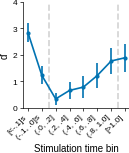

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(3.5 * CM_TO_INCHES, 3.5 * CM_TO_INCHES))

ax.axvline(1.5, color="lightgray", linestyle="--")
ax.axvline(6.5, color="lightgray", linestyle="--")

signal_detection_mean = (
    signal_detection[signal_detection["condition"] == "normal"]
    .groupby("timepoint_bin")["d_prime"]
    .mean()
)
signal_detection_sem = (
    signal_detection[signal_detection["condition"] == "normal"]
    .groupby("timepoint_bin")["d_prime"]
    .sem()
)

ax.errorbar(
    x=TIMEPOINT_ORDER,
    y=signal_detection_mean[TIMEPOINT_ORDER],
    yerr=CI95*signal_detection_sem[TIMEPOINT_ORDER],
    color=CONDITION_COLORS["normal"],
    fmt='o-',
)

ax.set(
    xlabel="Stimulation time bin",
    ylabel="d'",
    ylim=(0, 4),
    xticklabels=TIMEPOINT_LABELS
)



plt.xticks(rotation=45, ha="right")

plt.show()

## Kalman gain normal condition


In [4]:
# sigma0s = [INIT_SIGMA_POS_NORMAL-0.0005, INIT_SIGMA_POS_UNCERTAIN-0.0015]
sigma0s = [INIT_SIGMA_POS_NORMAL, INIT_SIGMA_POS_UNCERTAIN]
Ks = []
ts = []

for sigma0 in sigma0s:
    Sigma0 = jnp.eye(1 * 4) * jnp.array(1 * [sigma0, 1e-5, 1e-5, 1e-5])
    x0 = jnp.array(1 * [0.5, 0, 0, 0])
    todorov_spec = make_delayed_reaching_task_plus()
    Sigma_eps, K, L, _, _ = glqg.solve(
        lqgspec=todorov_spec,
        x0=x0,
        Sigma0=Sigma0 @ Sigma0.T,
    )

    key = jax.random.PRNGKey(0)
    Ks.append(K)

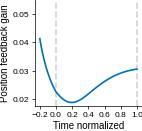

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(3.5 * CM_TO_INCHES, 3.5 * CM_TO_INCHES))
K = Ks[0]

ax.axvline(0, color="lightgray", linestyle="--")
ax.axvline(1, color="lightgray", linestyle="--")

ax.plot(
    np.append(np.arange(-0.2,0., 0.01), np.linspace(0,1, K.shape[0]-20)),
    K[:, 0, 0],
    color=CONDITION_COLORS["normal"],
)


ax.set(
    xlabel="Time normalized",
    ylabel="Position feedback gain",
    xticks=np.arange(-0.2,1.01, 0.2),
    ylim=(None,0.055)
)


plt.show()

## D Primes normal and initial uncertainty


/tmp/ipykernel_710544/2016695698.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(


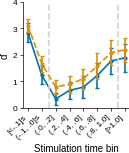

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(3.5 * CM_TO_INCHES, 3.5 * CM_TO_INCHES))

ax.axvline(1.5, color="lightgray", linestyle="--")
ax.axvline(6.5, color="lightgray", linestyle="--")

for condition, offset, zorder in zip(CONDITIONS, [-0.,0.], [1,2]):
    signal_detection_mean = (
        signal_detection[signal_detection["condition"] == condition]
        .groupby("timepoint_bin", sort=False)["d_prime"]
        .mean()
    )
    signal_detection_sem = (
        signal_detection[signal_detection["condition"] == condition]
        .groupby("timepoint_bin", sort=False)["d_prime"]
        .sem()
    )

    ax.errorbar(
        x=TIMEPOINT_ORDER,
        y=signal_detection_mean[TIMEPOINT_ORDER],
        fmt="o",
        yerr=CI95*signal_detection_sem[TIMEPOINT_ORDER],
        color=CONDITION_COLORS[condition],
        linestyle=CONDITION_LINESTYLES[condition],
        label=CONDITION_LABELS_DICT[condition],
        zorder=zorder,
        capsize=1.5
    )



plt.xticks(rotation=45, ha="right")
ax.set(
    xlabel="Stimulation time bin",
    ylabel="d'",
    ylim=(0, 4),
    xticklabels=TIMEPOINT_LABELS
)


plt.show()

## Kalman gain normal and initial uncertainty


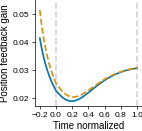

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(3.5 * CM_TO_INCHES, 3.5 * CM_TO_INCHES))

ax.axvline(0, color="lightgray", linestyle="--")
ax.axvline(1, color="lightgray", linestyle="--")


for K, condition in zip(Ks, CONDITIONS):
    ax.plot(
        np.append(np.arange(-0.2,0., 0.01), np.linspace(0,1, K.shape[0]-20)),
        K[:, 0, 0],
        color=CONDITION_COLORS[condition],
        linestyle=CONDITION_LINESTYLES[condition],
    )



ax.set(
    xlabel="Time normalized",
    ylabel="Position feedback gain",
    ylim=(None,0.055),
    xticks=np.arange(-0.2, 1.01, 0.2),
)


plt.show()

## Reaction times normal and uncertain


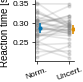

In [8]:
fig, ax = plot_subject_mean_condition(detection, "reaction_time")

ax.set(
    ylabel="Reaction time [s]",
)


plt.show()

## Movement time


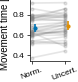

In [9]:
fig, ax = plot_subject_mean_condition(detection, "reach_time")

ax.set(
    ylabel="Movement time [s]",
)


plt.show()

## Time of maximum velocity


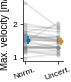

In [10]:
fig, ax = plot_subject_mean_condition(detection, "max_v")

ax.set(
    ylabel="Max. velocity [m/s]",
)


plt.show()

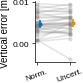

In [11]:
fig, ax = plot_subject_mean_condition(detection, "vertical_error")

ax.set(
    ylabel="Vertical error [m]",
    yticks=[0,0.01]
)


plt.show()

## Kalman gain vision and no vision


In [12]:
sigma_ps = [SIGMA_POS_VISION, SIGMA_POS_NO_VISION]
Ks_vis = []
ts_vis = []

for sigma_p in sigma_ps:
    Sigma0 = jnp.eye(1 * 4) * jnp.array(1 * [INIT_SIGMA_POS_NORMAL, 1e-5, 1e-5, 1e-5])
    x0 = jnp.array(1 * [0.3, 0, 0, 0])
    todorov_spec = make_delayed_reaching_task_plus(sigma_pos=sigma_p)
    Sigma_eps, K, L, _, _ = glqg.solve(
        lqgspec=todorov_spec,
        x0=x0,
        Sigma0=Sigma0 @ Sigma0.T,
    )

    key = jax.random.PRNGKey(0)
    trajectories, inov = glqg.simulate_different_start(
        key, 1000, todorov_spec, K, L, x0=x0, start_offset=0.03, delay=0
    )
    Ks_vis.append(K)
    ts_vis.append(trajectories)

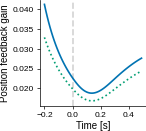

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(3.5 * CM_TO_INCHES, 3.5 * CM_TO_INCHES))


ax.axvline(0, color="lightgray", linestyle="--")

for K, condition in zip(Ks_vis, CONDITIONS[0::2]):
    ax.plot(
        np.arange(0, 70 * 0.01, 0.01) - 0.2,
        K[0:70, 0, 0],
        color=CONDITION_COLORS[condition],
        linestyle=CONDITION_LINESTYLES[condition],
    )



ax.set(
    xlabel="Time [s]",
    ylabel="Position feedback gain",
    xticks=np.arange(-0.2, 0.5, 0.2)
)


plt.show()

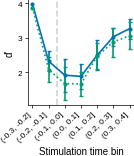

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(3.5 * CM_TO_INCHES, 3.5 * CM_TO_INCHES))

ax.axvline(1.5, color="lightgray", linestyle="--")

for condition, offset in zip(CONDITIONS[0::2], [-0.0,0.0]):
    condition_data = colino_plot_data[colino_plot_data["condition"] == condition]
    for bin in condition_data["bin"].unique():
        bin_data = condition_data[condition_data["bin"] == bin]
        if bin_data.shape[0] == 3:
            ax.errorbar(
                x=bin+offset,
                y=bin_data.loc[bin_data["identity"]=="mean", "d_prime"].values[0],
                yerr=np.array([[
                    bin_data.loc[bin_data["identity"]=="mean", "d_prime"].values[0] - bin_data.loc[bin_data["identity"]=="lower", "d_prime"].values[0],
                    bin_data.loc[bin_data["identity"]=="upper", "d_prime"].values[0] - bin_data.loc[bin_data["identity"]=="mean", "d_prime"].values[0],
                ]]).T,
                color=CONDITION_COLORS[condition],
                linestyle=CONDITION_LINESTYLES[condition],
                marker="o",
                capsize=1.5
            )
        else:
            ax.plot(
                bin_data["bin"]+offset,
                bin_data["d_prime"],
                color=CONDITION_COLORS[condition],
                linestyle=CONDITION_LINESTYLES[condition],
                marker="o",
            )
    ax.plot(
        condition_data.loc[condition_data["identity"]=="mean", "bin"]+offset,
        condition_data.loc[condition_data["identity"]=="mean", "d_prime"],
        color=CONDITION_COLORS[condition],
        linestyle=CONDITION_LINESTYLES[condition],
        marker=""
    )

ax.set(
    xticks=np.arange(7),
    xticklabels=[f"({i:.1f}, {i+0.1:.1f}]" for i in np.arange(-0.3, 0.4, 0.1)],
    xlabel="Stimulation time bin",
    ylabel="d'",
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")


plt.show()

# Masking-model comparison panels


In [15]:
CONDITIONS_MODEL_COMP = CONDITIONS[:-1]
subjects = sorted(reaches["subject"].unique())

T = detection["reach_time"].mean()

dt_norm = 0.01
padding = 0.2
dt = dt_norm * T
norm_grid = np.linspace(
    0.01, 0.97, 100
)  # only to 97 because of touch related artifacts at the end of accerelation profiles

mean_mt = {
    c: detection[detection["condition"] == c].groupby("subject")["reach_time"].mean()
    for c in CONDITIONS_MODEL_COMP
}
t_all = -padding + dt * np.arange(
    int(round((max(mt.max() for mt in mean_mt.values()) + 2 * padding) / dt)) + 1
)

profiles = {
    c: continuous_profiles(
        norm_time_profiles(reaches[reaches["condition"] == c], norm_grid),
        mean_mt[c],
        t_all,
        dt,
        padding,
        subjects,
    )
    for c in CONDITIONS_MODEL_COMP
}

In [16]:
sd_normal, d_prime_fit, d_prime, d_se = prep_condition(signal_detection, "normal")
sd_uncertain, d_prime_fit_unc, d_prime_uncertain, d_se_uncertain = prep_condition(
    signal_detection, "uncertain"
)

n_fit = len(d_prime_fit)
x_plot = np.arange(len(TIMEPOINT_LABELS))
subj_per_row = sd_normal["subject"].values
row_bin = sd_normal["timepoint_bin"].values
subj_bin_idx = pd.MultiIndex.from_arrays(
    [sd_normal["subject"], sd_normal["timepoint_bin"]]
)

bf = partial(
    bin_feature,
    t_grid=t_all,
    subject_per_row=subj_per_row,
    row_bins=row_bin,
    subjects=subjects,
    move_bins=MOVE_BINS,
    padding=padding,
)

In [17]:
FILTER_TAU_SYM = 0.05
FILTER_TAU_FWD = 0.05
FILTER_TAU_BWD = 0.07

In [18]:
K_normal_df = pd.DataFrame(
    {s: k_per_bin(simulated_Ks, "normal", s, MOVE_BINS) for s in subjects},
    index=TIMEPOINT_ORDER,
).T
K_uncertain_df = pd.DataFrame(
    {s: k_per_bin(simulated_Ks, "uncertain", s, MOVE_BINS) for s in subjects},
    index=TIMEPOINT_ORDER,
).T
K_per_row = K_normal_df.stack().loc[subj_bin_idx].values.astype(float)
K_uncertain_per_row = K_uncertain_df.stack().loc[subj_bin_idx].values.astype(float)

In [19]:
asym_fn = lambda sig: convolve_with_asymmetric_exponential(
    sig, FILTER_TAU_FWD, FILTER_TAU_BWD, dt
)
sym_fn = lambda sig: convolve_with_symmetric_exponential(sig, FILTER_TAU_SYM, dt)

X_normal = design_columns(
    "normal",
    profiles,
    mean_mt,
    {"normal": K_per_row, "uncertain": K_uncertain_per_row},
    bf,
    (asym_fn, sym_fn),
)
X_uncertain = design_columns(
    "uncertain",
    profiles,
    mean_mt,
    {"normal": K_per_row, "uncertain": K_uncertain_per_row},
    bf,
    (asym_fn, sym_fn),
)
fits = {
    name: fit_ps_linear(design, d_prime_fit, subjects, subj_per_row)
    for name, design in X_normal.items()
}

# Compute model statistics (R^2, MSE, log-likelihood, AIC, BIC) for each model fit.
# Add 6 parameters for the OFC K-gain model to account for the additional complexity of the model.
ps_stats = {
    name: model_stats(pred, d_prime_fit, k + 6 if name == "OFC K-gain" else k)
    for name, (pred, k, _) in fits.items()
}

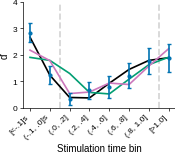

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(5 * CM_TO_INCHES, 3.5 * CM_TO_INCHES))

ax.axvline(1.5, color="lightgray", linestyle="--")
ax.axvline(6.5, color="lightgray", linestyle="--")

ax.errorbar(
    x_plot,
    d_prime,
    yerr=CI95 * d_se,
    fmt="o",
    color=CONDITION_COLORS["normal"],
    capsize=1.5,
    label="data",
    zorder=4,
)

for name in ["OFC K-gain", "Conv vel (Asym)", "Conv acc (Asym)"]:
    ax.plot(x_plot, bin_mean(fits[name][0], row_bin), "-", color=MODEL_COLORS[name], label=name)

ax.set(
    xlabel="Stimulation time bin",
    ylabel="d'",
    ylim=(0, 4),
    xticks=x_plot,
    xticklabels=TIMEPOINT_LABELS,
)
plt.xticks(rotation=45, ha="right")
# ax.legend(fontsize=5, loc="upper center")
plt.show()

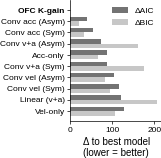

In [21]:
order = sorted(ps_stats, key=lambda n: ps_stats[n][3])  # ascending AIC, best first
aic0 = min(ps_stats[n][3] for n in ps_stats)
bic0 = min(ps_stats[n][4] for n in ps_stats)
d_aic = [ps_stats[n][3] - aic0 for n in order]
d_bic = [ps_stats[n][4] - bic0 for n in order]
y, h = np.arange(len(order)), 0.4

fig, ax = plt.subplots(1, 1, figsize=(3 * CM_TO_INCHES, 4 * CM_TO_INCHES))
ax.barh(y - h / 2, d_aic, height=h, color="0.45", label="ΔAIC")
ax.barh(y + h / 2, d_bic, height=h, color="0.78", label="ΔBIC")
ax.set(yticks=y, yticklabels=order, xlabel="Δ to best model\n(lower = better)")
ax.invert_yaxis()
for lbl in ax.get_yticklabels():
    if lbl.get_text() == "OFC K-gain":
        lbl.set_fontweight("bold")
ax.legend(loc="upper right")
plt.show()

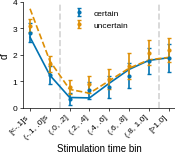

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(5 * CM_TO_INCHES, 3.5 * CM_TO_INCHES))

ax.axvline(1.5, color="lightgray", linestyle="--")
ax.axvline(6.5, color="lightgray", linestyle="--")

name = "OFC K-gain"
coefs = fits[name][2]
preds = {
    "normal": bin_mean(predict_with_coefs(X_normal[name], coefs, subj_per_row), row_bin),
    "uncertain": bin_mean(predict_with_coefs(X_uncertain[name], coefs, subj_per_row), row_bin),
}
data = {"normal": (d_prime, d_se), "uncertain": (d_prime_uncertain, d_se_uncertain)}

for cond in ["normal", "uncertain"]:
    dp, se = data[cond]
    ax.errorbar(
        x_plot,
        dp,
        yerr=CI95 * se,
        fmt="o",
        color=CONDITION_COLORS[cond],
        capsize=1.5,
        label=CONDITION_LABELS_DICT[cond],
        zorder=3,
    )
    ax.plot(
        x_plot,
        preds[cond],
        color=CONDITION_COLORS[cond],
        linestyle=CONDITION_LINESTYLES[cond],
    )

ax.set(
    xlabel="Stimulation time bin",
    ylabel="d'",
    ylim=(0, 4),
    xticks=x_plot,
    xticklabels=TIMEPOINT_LABELS,
)
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.show()

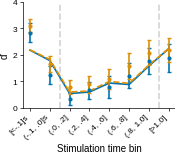

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(5 * CM_TO_INCHES, 3.5 * CM_TO_INCHES))

ax.axvline(1.5, color="lightgray", linestyle="--")
ax.axvline(6.5, color="lightgray", linestyle="--")

name = "Conv acc (Asym)"
coefs = fits[name][2]
preds = {
    "normal": bin_mean(predict_with_coefs(X_normal[name], coefs, subj_per_row), row_bin),
    "uncertain": bin_mean(predict_with_coefs(X_uncertain[name], coefs, subj_per_row), row_bin),
}
data = {"normal": (d_prime, d_se), "uncertain": (d_prime_uncertain, d_se_uncertain)}

for cond in ["normal", "uncertain"]:
    dp, se = data[cond]
    ax.errorbar(
        x_plot,
        dp,
        yerr=CI95 * se,
        fmt="o",
        color=CONDITION_COLORS[cond],
        capsize=1.5,
        label=CONDITION_LABELS_DICT[cond],
        zorder=3,
    )
    ax.plot(
        x_plot,
        preds[cond],
        color=CONDITION_COLORS[cond],
        linestyle=CONDITION_LINESTYLES[cond],
    )

ax.set(
    xlabel="Stimulation time bin",
    ylabel="d'",
    ylim=(0, 4),
    xticks=x_plot,
    xticklabels=TIMEPOINT_LABELS,
)
plt.xticks(rotation=45, ha="right")
# ax.legend()
plt.show()

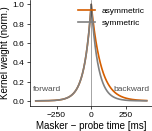

In [24]:
# Both fixed-shape masking kernels, normalized to unit peak: the asymmetric
# exponential (heavy right tail = backward masking stronger than forward) and the
# symmetric exponential.
tau_axis = np.arange(-0.4, 0.4 + dt / 100, dt / 100)
k_asym = asymmetric_exponential_kernel(tau_axis, FILTER_TAU_FWD, FILTER_TAU_BWD)
k_asym = k_asym / k_asym.max()
k_sym = symmetric_exponential_kernel(tau_axis, FILTER_TAU_SYM)
k_sym = k_sym / k_sym.max()

fig, ax = plt.subplots(1, 1, figsize=(4 * CM_TO_INCHES, 3.5 * CM_TO_INCHES))
ax.plot(tau_axis * 1000, k_asym, color=MODEL_COLORS["Conv v+a (Asym)"], label="asymmetric")
ax.plot(tau_axis * 1000, k_sym, color="0.5", label="symmetric")
ax.axvline(0, color="k", lw=0.5, alpha=0.5)
ax.text(
    0.02,
    0.12,
    "forward",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=6,
    color="0.3",
)
ax.text(
    0.98,
    0.12,
    "backward",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=6,
    color="0.3",
)
ax.set(xlabel="Masker − probe time [ms]", ylabel="Kernel weight (norm.)")
ax.legend(fontsize=6, loc="upper right")
plt.show()

In [54]:
# bin_name = "(-inf, -0.1]"
bin_name = "(-0.1, 0.0]"

bi = TIMEPOINT_ORDER.index(bin_name)

delta_d_prime_bin = {
    name: (
        bin_mean(predict_with_coefs(X_uncertain[name], fits[name][2], subj_per_row), row_bin)[bi]
        - bin_mean(predict_with_coefs(X_normal[name], fits[name][2], subj_per_row), row_bin)[bi]
    )
    for name in fits
}
delta_d_prime_bin["data (observed)"] = d_prime_uncertain[bi] - d_prime[bi]

delta_d_prime_bin = (
    pd.Series(delta_d_prime_bin, name=f"Δd′ (uncertain − normal), bin {bin_name}")
    .round(3)
    .to_frame()
)
delta_d_prime_bin

,"Δd′ (uncertain − normal), bin (-0.1, 0.0]"
Vel-only,0.000
Acc-only,0.000
Linear (v+a),0.000
Conv vel (Asym),0.013
Conv vel (Sym),0.008
Conv acc (Asym),0.042
Conv acc (Sym),0.032
Conv v+a (Asym),0.046
Conv v+a (Sym),0.035
OFC K-gain,0.538


# Kinematics data and model
## Human kinematics

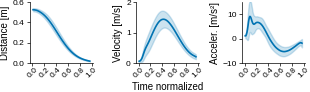

In [25]:
kin = {
    c: norm_profiles_signed(reaches[reaches["condition"] == c], norm_grid, ("d", "v", "a"))
    for c in CONDITIONS_MODEL_COMP
}

plot_kinematics(["normal"], kin, norm_grid)
plt.show()

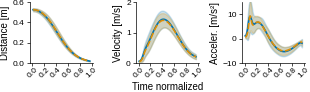

In [26]:
plot_kinematics(["normal", "uncertain"], kin, norm_grid)
plt.show()

## Simulated Kinematics

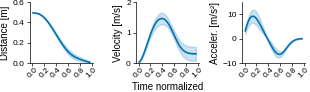

In [27]:
simulated_for_averaging = simulated_trajectories.rename(columns={"reach_i": "trial"})

kin_simulated = {
    condition: norm_profiles_signed(
        simulated_for_averaging[simulated_for_averaging["condition"] == condition],
        norm_grid,
        ("d", "v", "a"),
    )
    for condition in CONDITIONS_MODEL_COMP
}

plot_kinematics(["normal"], kin_simulated, norm_grid)
plt.show()

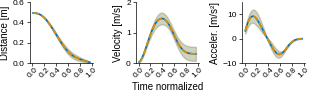

In [28]:
plot_kinematics(["normal", "uncertain"], kin_simulated, norm_grid)
plt.show()

## SI Signal detection theory
### All Subjects


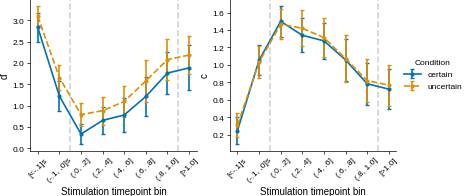

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12*CM_TO_INCHES, 5*CM_TO_INCHES))

for ax in axes:
    ax.axvline(1.5, color="lightgray", linestyle="--")
    ax.axvline(6.5, color="lightgray", linestyle="--")

x = np.arange(len(TIMEPOINT_ORDER))
conditions = CONDITIONS[:2]

for condition in conditions:
    condition_data = signal_detection[signal_detection["condition"] == condition]

    dprime_mean = (
        condition_data.groupby("timepoint_bin")["d_prime"]
        .mean()
        .reindex(TIMEPOINT_ORDER)
    )
    dprime_sem = (
        condition_data.groupby("timepoint_bin")["d_prime"]
        .sem()
        .reindex(TIMEPOINT_ORDER)
    )

    criterion_mean = (
        condition_data.groupby("timepoint_bin")["criterion"]
        .mean()
        .reindex(TIMEPOINT_ORDER)
    )
    criterion_sem = (
        condition_data.groupby("timepoint_bin")["criterion"]
        .sem()
        .reindex(TIMEPOINT_ORDER)
    )

    axes[0].errorbar(
        x,
        dprime_mean.values,
        yerr=CI95*dprime_sem.values,
        fmt="o",
        linestyle = CONDITION_LINESTYLES[condition],
        color=CONDITION_COLORS[condition],
        label=CONDITION_LABELS_DICT[condition],
        capsize=1.5,
    )

    axes[1].errorbar(
        x,
        criterion_mean.values,
        yerr=CI95*criterion_sem.values,
        fmt="o",
        linestyle = CONDITION_LINESTYLES[condition],
        color=CONDITION_COLORS[condition],
        label=CONDITION_LABELS_DICT[condition],
        capsize=1.5,
    )

axes[0].set(
    xlabel="Stimulation timepoint bin",
    ylabel="d'",
    xticks=x,
    xticklabels=TIMEPOINT_LABELS,
    )
axes[0].tick_params(axis="x", rotation=45)

axes[1].set(
    xlabel="Stimulation timepoint bin",
    ylabel="c",
    xticks=x,
    xticklabels=TIMEPOINT_LABELS,
    )
axes[1].tick_params(axis="x", rotation=45)

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    title="Condition",
)


plt.show()

### Single subjects


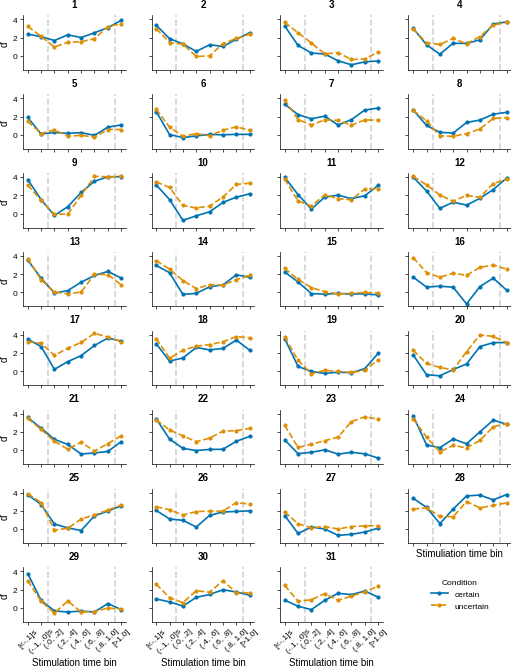

In [30]:
fig, axes = plt.subplots(
    8, 4, figsize=(16 * CM_TO_INCHES, 20 * CM_TO_INCHES), sharex=True, sharey=True
 )
fig.subplots_adjust(hspace=0.45, wspace=0.25)

axes_flat = axes.flatten()
subject_axes = axes_flat[:-1]
legend_ax = axes_flat[-1]

subjects = sorted(signal_detection["subject"].unique())


conditions = CONDITIONS[:2]
x = np.arange(len(TIMEPOINT_ORDER))

for ax, subject in zip(subject_axes, subjects):
    subject_data = signal_detection[signal_detection["subject"] == subject]

    ax.axvline(1.5, color="lightgray", linestyle="--")
    ax.axvline(6.5, color="lightgray", linestyle="--")

    for condition in conditions:
        condition_data = subject_data[subject_data["condition"] == condition]
        dprime_mean = (
            condition_data.groupby("timepoint_bin")["d_prime"]
            .mean()
            .reindex(TIMEPOINT_ORDER)
        )

        ax.plot(
            x,
            dprime_mean.values,
            marker="o",
            linestyle=CONDITION_LINESTYLES[condition],
            color=CONDITION_COLORS[condition],
            label=CONDITION_LABELS_DICT[condition],
        )

    ax.set(
        title=str(subject),
        xticks=x,
        xticklabels=TIMEPOINT_LABELS,
    )
    ax.tick_params(axis="x", labelrotation=45)

for ax in subject_axes[len(subjects):]:
    ax.axis("off")

legend_ax.axis("off")
handles, labels = subject_axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc="center", title="Condition")

for ax in axes[-1, :-1]:
    ax.set(xlabel="Stimulation time bin")
axes[-2, -1].set(xlabel="Stimuliation time bin")

for ax in axes[:, 0]:
    ax.set(ylabel="d'")

plt.show()

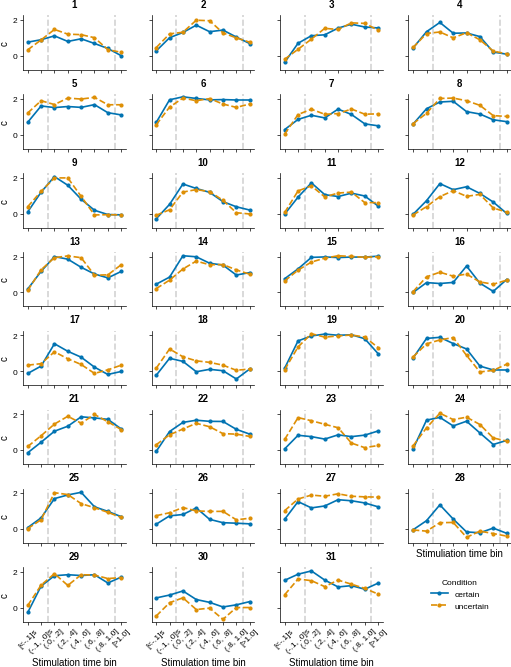

In [31]:
fig, axes = plt.subplots(
    8, 4, figsize=(16 * CM_TO_INCHES, 20 * CM_TO_INCHES), sharex=True, sharey=True
)
fig.subplots_adjust(hspace=0.45, wspace=0.25)

axes_flat = axes.flatten()
subject_axes = axes_flat[:-1]
legend_ax = axes_flat[-1]

subjects = sorted(signal_detection["subject"].unique())
if len(subjects) > len(subject_axes):
    raise ValueError(
        f"Found {len(subjects)} subjects but only {len(subject_axes)} subject panels are available in an 8x4 grid."
    )

conditions = CONDITIONS[:2]
x = np.arange(len(TIMEPOINT_ORDER))

for ax, subject in zip(subject_axes, subjects):
    subject_data = signal_detection[signal_detection["subject"] == subject]

    ax.axvline(1.5, color="lightgray", linestyle="--")
    ax.axvline(6.5, color="lightgray", linestyle="--")

    for condition in conditions:
        condition_data = subject_data[subject_data["condition"] == condition]
        criterion_mean = (
            condition_data.groupby("timepoint_bin")["criterion"]
            .mean()
            .reindex(TIMEPOINT_ORDER)
        )

        ax.plot(
            x,
            criterion_mean.values,
            marker="o",
            linestyle=CONDITION_LINESTYLES[condition],
            color=CONDITION_COLORS[condition],
            label=CONDITION_LABELS_DICT[condition],
        )

    ax.set(
        title=str(subject),
        xticks=x,
        xticklabels=TIMEPOINT_LABELS,
    )
    ax.tick_params(axis="x", labelrotation=45)

for ax in subject_axes[len(subjects):]:
    ax.axis("off")

legend_ax.axis("off")
handles, labels = subject_axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc="center", title="Condition")

for ax in axes[-1, :-1]:
    ax.set(xlabel="Stimulation time bin")
axes[-2, -1].set(xlabel="Stimuliation time bin")

for ax in axes[:, 0]:
    ax.set(ylabel="c")

plt.show()

# SI Robustness analysis


In [32]:
params_order = ["sigma0", "sigma_pos", "sigma_vel", "sigma_frc", "v", "f", "r", "c"]

scales_standard = np.array([0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0])
scales_param = {
    "sigma0": np.array([0.6, 0.75, 0.9, 1.0, 1.1, 1.25, 1.4]),
    "sigma_pos": np.array([0.6, 0.75, 0.9, 1.0, 1.1, 1.25, 1.4]),
}

res = {}
for param in params_order:
    try:
        scales = scales_param[param]
    except:
        scales = scales_standard
    res[param] = solve_for_param_scaled(param, scales)

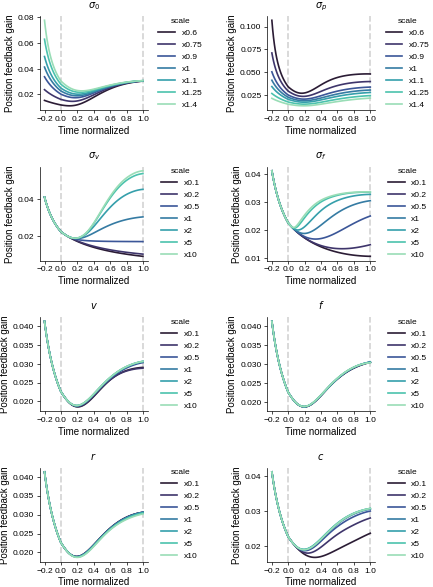

In [33]:
fig, axes = plt.subplots(4, 2, figsize=(11*CM_TO_INCHES, 18*CM_TO_INCHES))
fig.subplots_adjust(hspace=0.6, wspace=1.1)

axes_flat = axes.flatten()

for ax, param in zip(axes_flat, params_order):

    ax.axvline(0, color="lightgray", linestyle="--")
    ax.axvline(1, color="lightgray", linestyle="--")

    K_series, labels = res[param]
    t = np.append(np.arange(-0.2,0., 0.01), np.linspace(0,1, 70))

    for K_mat, lab, color in zip(K_series, labels, sns.color_palette("mako", 7)):
        ax.plot(t, K_mat[:, 0, 0], label=lab, color=color)

    if param[:6] == "sigma0":
        ax.set_title(r"$\sigma_{0}$")
    elif param[:5] == "sigma":
        ax.set_title(r"$\sigma_{"+param[6:7]+"}$")
    else:
        ax.set_title(r"$"+param+"$")
    
    ax.set(
        xlabel="Time normalized",
        ylabel="Position feedback gain",
        xticks=np.arange(-0.2,1.01, 0.2),
    )

    ax.legend(title="scale",
        bbox_to_anchor=(1.3, 0.5),
        loc="center",
    )


plt.show()

In [34]:
robustness_res = pd.read_csv("../data/robustness_oc_gains.csv")

In [35]:
K_pos = robustness_res[[f"K_pos_{t}" for t in range(90)]].values
K_pos_norm = K_pos / np.max(K_pos, axis=1, keepdims=True)
mean = np.mean(K_pos_norm, axis=0)
percentile_025 = np.percentile(K_pos_norm, 2.5, axis=0)
percentile_975 = np.percentile(K_pos_norm, 97.5, axis=0)
std = np.std(K_pos_norm, axis=0)


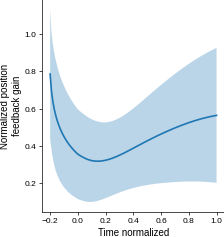

In [36]:
fig, ax = plt.subplots(figsize=(6*CM_TO_INCHES, 7*CM_TO_INCHES))

ax.plot(
    np.append(np.arange(-0.2,0., 0.01), np.linspace(0,1, 70)),
    mean,
    label="mean",
)
ax.fill_between(
    np.append(np.arange(-0.2,0., 0.01), np.linspace(0,1, 70)),
    mean - std,
    mean + std,
    alpha=0.3,
    label="std",
)

ax.set(
    xlabel="Time normalized",
    ylabel="Normalized position\nfeedback gain",
)

plt.show()

# SI model comparison

In [37]:
best = min(ps_stats, key=lambda n: ps_stats[n][3])  # lowest AIC
aic0 = ps_stats[best][3]
bic0 = min(ps_stats[n][4] for n in ps_stats)
order = sorted(ps_stats, key=lambda n: ps_stats[n][3])  # best (lowest AIC) first

model_comparison_table = pd.DataFrame(
    {
        r"$k$": [f"{fits[n][1]:d}" if n != "OFC K-gain" else f"{fits[n][1]+6:d}" for n in order],
        r"$R^2$": [f"{ps_stats[n][0]:.3f}" for n in order],
        r"MSE": [f"{ps_stats[n][1]:.3f}" for n in order],
        r"AIC": [f"{ps_stats[n][3]:.1f}" for n in order],
        r"$\Delta$AIC": [f"{ps_stats[n][3] - aic0:.1f}" for n in order],
        r"BIC": [f"{ps_stats[n][4]:.1f}" for n in order],
        r"$\Delta$BIC": [f"{ps_stats[n][4] - bic0:.1f}" for n in order],
    },
    index=[f"\\textbf{{{n}}}" if n == best else n for n in order],
)
model_comparison_table.index.name = "Model"

print(
    model_comparison_table.to_latex(
        escape=False,
        column_format="l" + "r" * 7,
        caption=(
            r"Model comparison on the \textit{certain} condition. "
            r"$k$: number of free parameters; $R^2$ and MSE: goodness of fit; AIC and BIC: "
            r"information criteria, with $\Delta$AIC and $\Delta$BIC the difference to the "
            r"best model. Models are ordered by AIC and the best model is in bold."
        ),
        label="tab:model_comparison",
    )
)
model_comparison_table

\begin{table}
\caption{Model comparison on the \textit{certain} condition. $k$: number of free parameters; $R^2$ and MSE: goodness of fit; AIC and BIC: information criteria, with $\Delta$AIC and $\Delta$BIC the difference to the best model. Models are ordered by AIC and the best model is in bold.}
\label{tab:model_comparison}
\begin{tabular}{lrrrrrrr}
\toprule
 & $k$ & $R^2$ & MSE & AIC & $\Delta$AIC & BIC & $\Delta$BIC \\
Model &  &  &  &  &  &  &  \\
\midrule
\textbf{OFC K-gain} & 68 & 0.759 & 0.417 & 622.8 & 0.0 & 861.7 & 0.0 \\
Conv acc (Asym) & 62 & 0.702 & 0.515 & 663.4 & 40.6 & 881.2 & 19.5 \\
Conv acc (Sym) & 62 & 0.685 & 0.544 & 677.0 & 54.2 & 894.9 & 33.2 \\
Conv v+a (Asym) & 93 & 0.735 & 0.457 & 695.8 & 73.0 & 1022.5 & 160.8 \\
Acc-only & 62 & 0.640 & 0.621 & 709.6 & 86.8 & 927.5 & 65.8 \\
Conv v+a (Sym) & 93 & 0.719 & 0.486 & 710.9 & 88.1 & 1037.6 & 175.9 \\
Conv vel (Asym) & 62 & 0.614 & 0.666 & 727.0 & 104.2 & 944.8 & 83.1 \\
Conv vel (Sym) & 62 & 0.594 & 0.700 & 739.5 & 

,$k$,$R^2$,MSE,AIC,$\Delta$AIC,BIC,$\Delta$BIC
Model,,,,,,,
\textbf{OFC K-gain},68,0.759,0.417,622.8,0.0,861.7,0.0
Conv acc (Asym),62,0.702,0.515,663.4,40.6,881.2,19.5
Conv acc (Sym),62,0.685,0.544,677.0,54.2,894.9,33.2
Conv v+a (Asym),93,0.735,0.457,695.8,73.0,1022.5,160.8
Acc-only,62,0.640,0.621,709.6,86.8,927.5,65.8
Conv v+a (Sym),93,0.719,0.486,710.9,88.1,1037.6,175.9
Conv vel (Asym),62,0.614,0.666,727.0,104.2,944.8,83.1
Conv vel (Sym),62,0.594,0.700,739.5,116.7,957.3,95.6
Linear (v+a),93,0.680,0.552,742.5,119.7,1069.2,207.5


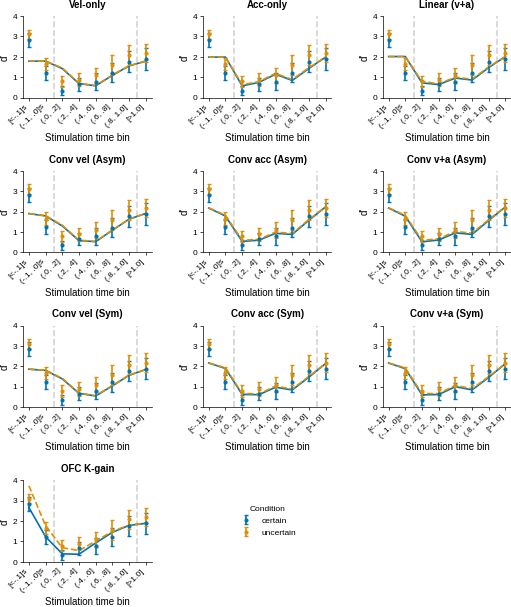

In [38]:
layout = [
    ["Vel-only", "Acc-only", "Linear (v+a)"],
    ["Conv vel (Asym)", "Conv acc (Asym)", "Conv v+a (Asym)"],
    ["Conv vel (Sym)", "Conv acc (Sym)", "Conv v+a (Sym)"],
    ["OFC K-gain", None, None],
]

fig, axes = plt.subplots(4, 3, figsize=(16 * CM_TO_INCHES, 18 * CM_TO_INCHES))
fig.subplots_adjust(hspace=0.9, wspace=0.4)

data = {"normal": (d_prime, d_se), "uncertain": (d_prime_uncertain, d_se_uncertain)}

for name, ax in zip([n for row in layout for n in row], axes.flat):
    if name is None:
        ax.axis("off")
        continue

    ax.axvline(1.5, color="lightgray", linestyle="--")
    ax.axvline(6.5, color="lightgray", linestyle="--")

    coefs = fits[name][2]
    preds = {
        "normal": bin_mean(predict_with_coefs(X_normal[name], coefs, subj_per_row), row_bin),
        "uncertain": bin_mean(predict_with_coefs(X_uncertain[name], coefs, subj_per_row), row_bin),
    }

    for cond in ["normal", "uncertain"]:
        dp, se = data[cond]
        ax.errorbar(
            x_plot,
            dp,
            yerr=CI95 * se,
            fmt="o",
            color=CONDITION_COLORS[cond],
            capsize=1.5,
            label=CONDITION_LABELS_DICT[cond],
            zorder=3,
        )
        ax.plot(
            x_plot,
            preds[cond],
            color=CONDITION_COLORS[cond],
            linestyle=CONDITION_LINESTYLES[cond],
        )

    ax.set(
        xlabel="Stimulation time bin",
        ylabel="d'",
        ylim=(0, 4),
        xticks=x_plot,
        title=name,
    )
    ax.set_xticklabels(TIMEPOINT_LABELS, rotation=45, ha="right")

# single condition legend in a free panel of the last row
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[3, 1].legend(handles, labels, loc="center", title="Condition")

plt.show()